# Test Inference

This notebook evaluates the trained YOLOv8 models on unseen test images and visualizes detection results.

The objective is to assess qualitative performance and compare detection behavior between YOLOv8n and YOLOv8s.

In [11]:
from pathlib import Path
from ultralytics import YOLO
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
ROOT = Path("..").resolve()
DATASET = ROOT / "dataset_yolo_detection"

print(DATASET.exists())

True


Load models

In [2]:
model_n = YOLO(ROOT / "runs" / "detect" / "runs_detection" / "yolov8n_baseline_1024" / "weights" / "best.pt")
model_s = YOLO(ROOT / "runs" / "detect" / "runs_detection" / "yolov8s_baseline_1024" / "weights" / "best.pt")

print("Models loaded successfully.")

Models loaded successfully.


Select Test Images

In [7]:
test_images = list((DATASET / "images" / "test").glob("*.jpg"))

print(f"Test images: {len(test_images)}")

Test images: 2101


## Run Inference

The trained YOLOv8n and YOLOv8s models are evaluated on unseen test images.

Predictions are generated using a confidence threshold of 0.25. A subset of test images is used for qualitative comparison and visualization.

In [18]:
random.seed(42)
sample_images = random.sample(test_images, 20)

results_n = model_n.predict(
    source=sample_images,
    conf=0.25,
    verbose=False
)

results_s = model_s.predict(
    source=sample_images,
    conf=0.25,
    verbose=False
)

print("YOLOv8n predictions:", len(results_n))
print("YOLOv8s predictions:", len(results_s))

YOLOv8n predictions: 20
YOLOv8s predictions: 20


## Detection Statistics

This section compares the number of detected objects produced by each model on the selected test images.

In [19]:
detections_n = [len(r.boxes) for r in results_n]
detections_s = [len(r.boxes) for r in results_s]

comparison = pd.DataFrame({
    "image": range(len(sample_images)),
    "YOLOv8n": detections_n,
    "YOLOv8s": detections_s
})

display(comparison.head())

,image,YOLOv8n,YOLOv8s
0,0,5,1
1,1,5,4
2,2,0,0
3,3,0,0
4,4,2,1


## Prediction Visualization

Representative predictions from both models are visualized to assess qualitative detection performance.

In [13]:
def show_prediction(result, title):
    img = result.plot()

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

### Show first 3 images

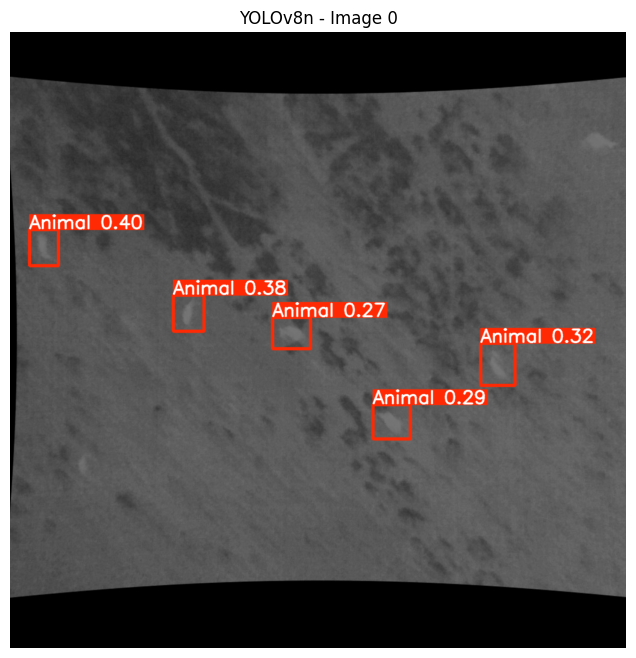

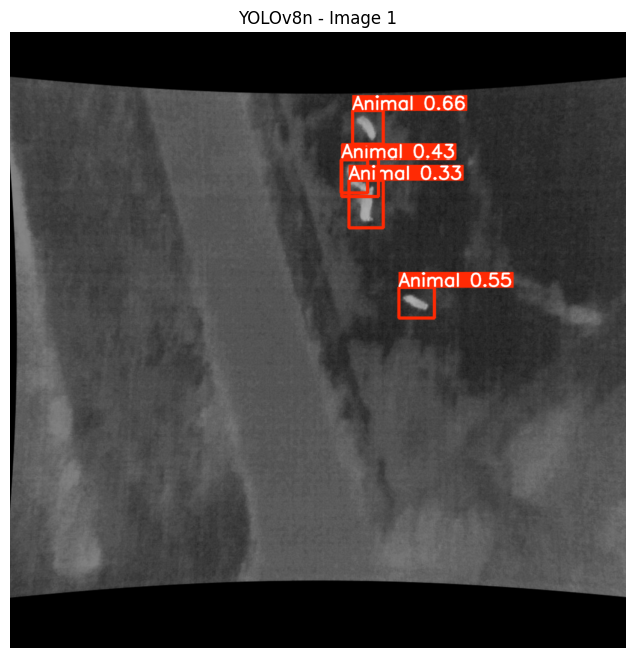

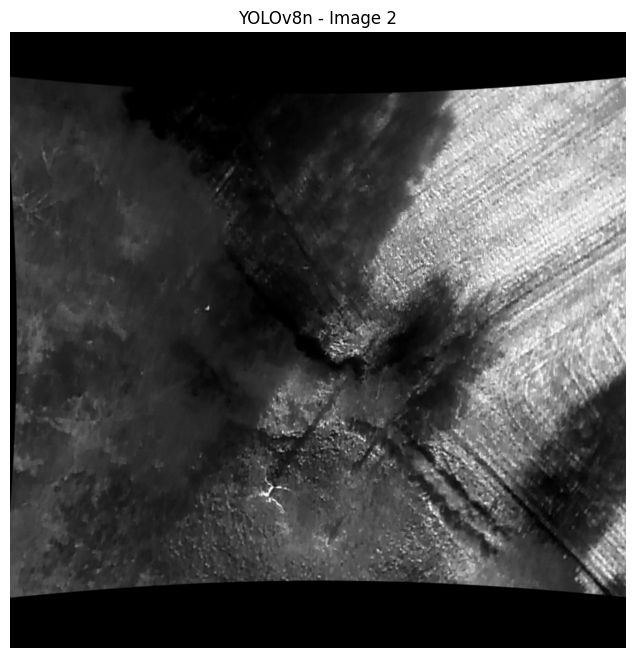

In [20]:
for i in range(3):
    show_prediction(results_n[i], f"YOLOv8n - Image {i}")

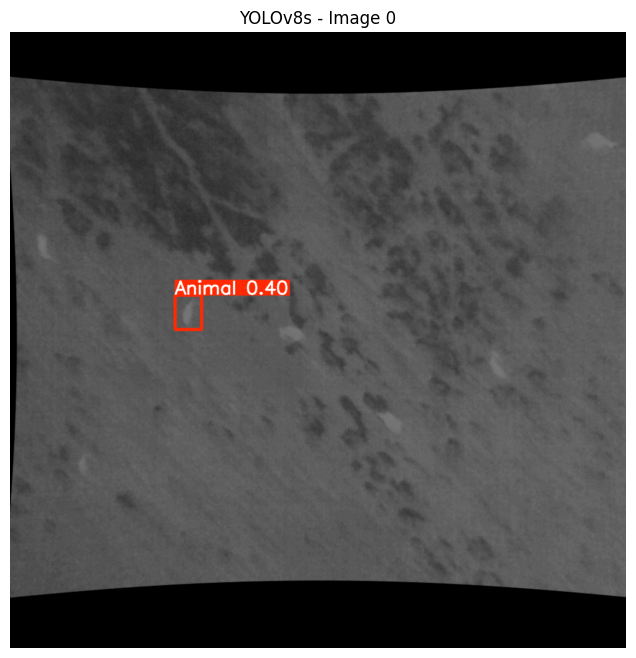

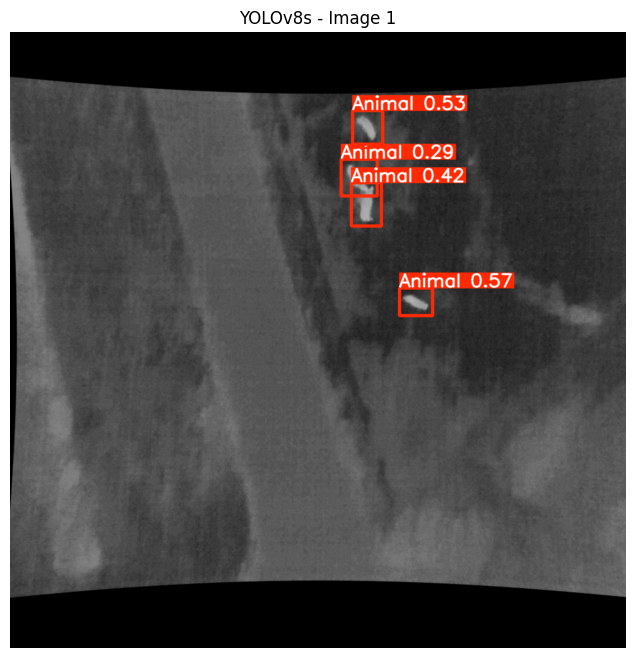

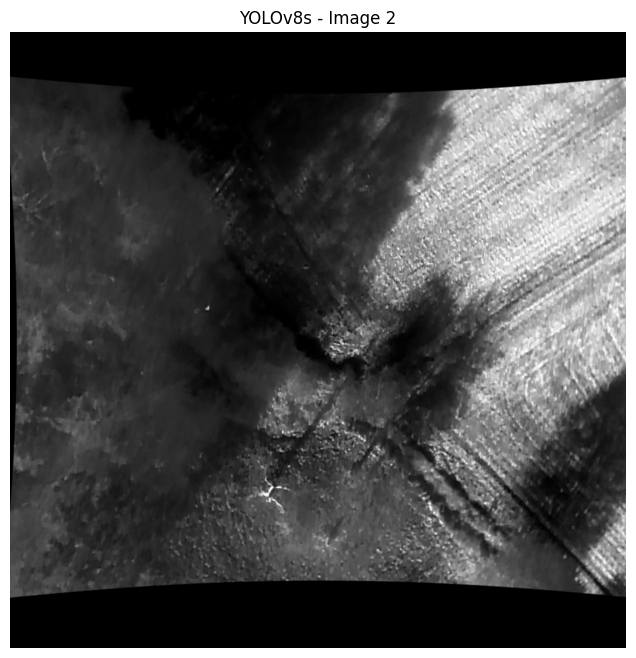

In [21]:
for i in range(3):
    show_prediction(results_s[i], f"YOLOv8s - Image {i}")

### Side by Side Comparison

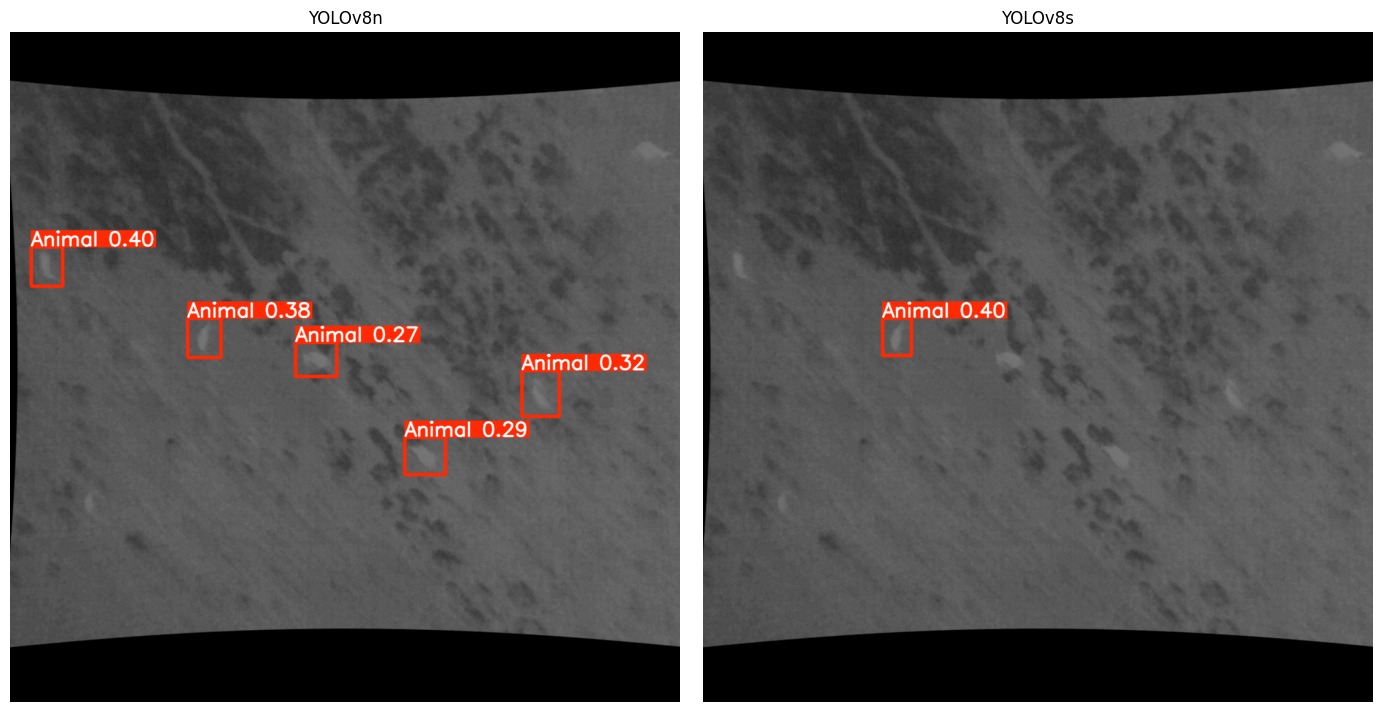

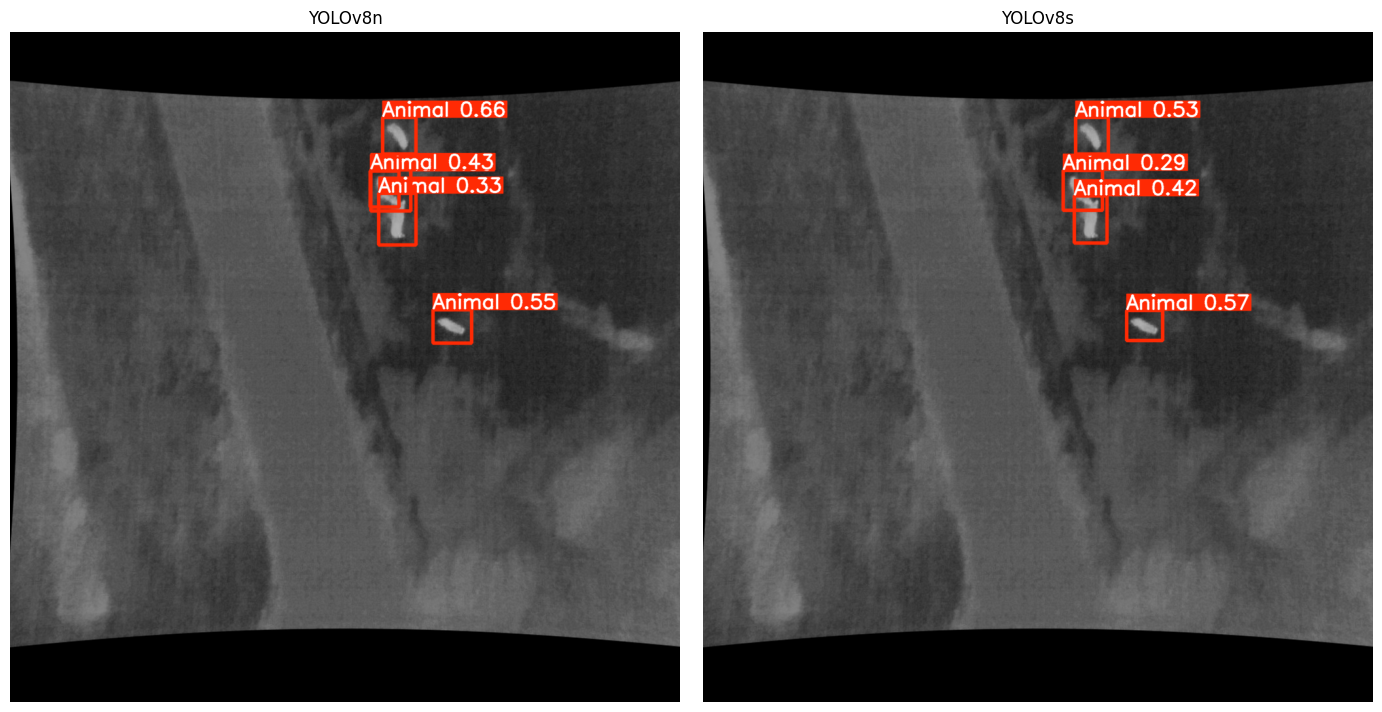

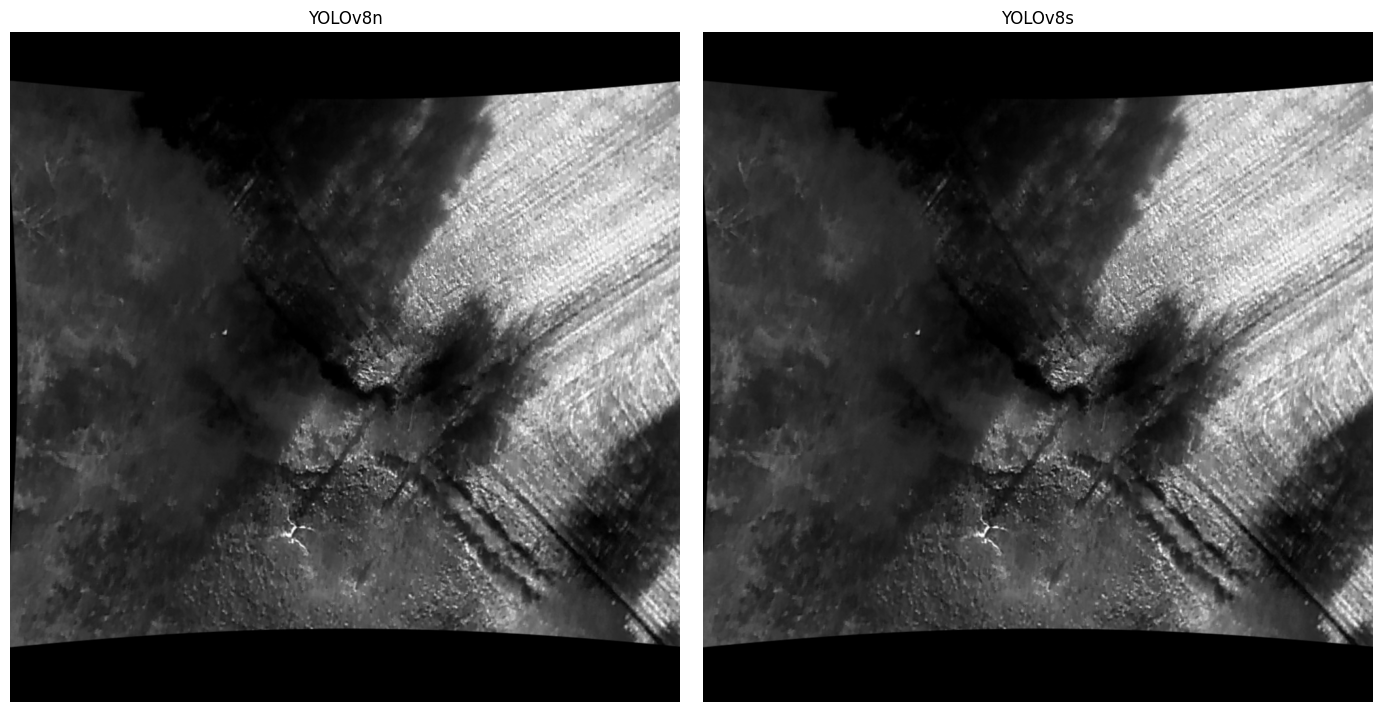

In [22]:
for i in range(3):

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(results_n[i].plot())
    axes[0].set_title("YOLOv8n")
    axes[0].axis("off")

    axes[1].imshow(results_s[i].plot())
    axes[1].set_title("YOLOv8s")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [23]:
comparison["difference"] = (
    comparison["YOLOv8n"]
    - comparison["YOLOv8s"]
)

display(comparison.describe())

,image,YOLOv8n,YOLOv8s,difference
count,20.00000,20.000000,20.000000,20.000000
mean,9.50000,1.450000,1.150000,0.300000
std,5.91608,1.700619,1.268028,1.080935
min,0.00000,0.000000,0.000000,-1.000000
25%,4.75000,0.000000,0.000000,0.000000
50%,9.50000,1.000000,1.000000,0.000000
75%,14.25000,2.250000,1.250000,1.000000
max,19.00000,5.000000,4.000000,4.000000


In [24]:
print("YOLOv8n average detections:", comparison["YOLOv8n"].mean())
print("YOLOv8s average detections:", comparison["YOLOv8s"].mean())

YOLOv8n average detections: 1.45
YOLOv8s average detections: 1.15


## Final Observations

Both YOLOv8n and YOLOv8s successfully detected animals in unseen thermal test images.

Qualitative inspection showed that the models generally agreed on object locations and classifications. YOLOv8n produced slightly more detections on average (1.45 detections per image) compared with YOLOv8s (1.15 detections per image), indicating a tendency to generate more candidate detections.

Some detections generated by YOLOv8n occurred at low confidence levels and were not detected by YOLOv8s. This behaviour is consistent with the quantitative evaluation results obtained during validation.

Overall, both models demonstrated the ability to generalize to unseen thermal imagery, with YOLOv8s achieving slightly higher recall and YOLOv8n producing slightly more detections.